In [2]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
cwd = os.getcwd()
words = open(cwd + '/../' + 'names.txt', 'r').read().splitlines()

In [4]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
# mapping chars to index
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
# mapping index to char
itos = {i:s for s,i in stoi.items()}

In [6]:
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [111]:
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size
    #print(w)
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [15]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [19]:
# Embedding in a smaller space (lookup table) -> 27 letters into a smaller space of size 2 (arbitrary)
C = torch.randn((27,2))

In [28]:
C[5]

tensor([ 1.0791, -1.0293])

In [31]:
# The one_hot encoding acts as a mask
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 1.0791, -1.0293])

In [34]:
C[X].shape

torch.Size([32, 3, 2])

In [36]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [40]:
emb = C[X]
# emb @ W1 + b1 -> this does not work since emb has shape (32,3,2)

torch.Size([32, 6])

In [43]:
torch.cat((emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]), dim=1).shape

# why to generalize the previous hardcoded command -> concatenation is an ineffiecient command, it creates a new tensor
torch.cat(torch.unbind(emb, 1), dim=1).shape

torch.Size([32, 6])

In [46]:
# a more efficient solution is to use view()
emb.view(32,6) == torch.cat(torch.unbind(emb, 1), dim=1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [50]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
# the addition of b1 is correct because:
# 32, 100
#  1, 100 -> they align at right if fewer dimensions

In [48]:
h

tensor([[-0.8819,  0.9548,  0.9847,  ...,  0.9083, -0.7411, -0.6226],
        [-0.8815,  0.9999,  0.9676,  ..., -0.7801, -0.4080,  0.9727],
        [ 0.8540,  0.9648,  0.9758,  ...,  0.9891,  0.3393, -0.9555],
        ...,
        [-0.9863,  0.9992, -0.9910,  ..., -0.9992, -0.2317,  0.4289],
        [ 0.6709,  0.9999,  0.7721,  ..., -0.3146,  0.6979,  0.0499],
        [ 0.1272,  1.0000,  0.4917,  ..., -0.9666,  0.3962,  0.9897]])

In [52]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [53]:
logits = h @ W2 + b2

In [54]:
logits.shape

torch.Size([32, 27])

In [58]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
prob.shape

torch.Size([32, 27])

In [60]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(16.8379)

In [61]:
# ---- Clean up and made visualization better ----

In [280]:
def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182424, 3]) torch.Size([182424])
torch.Size([22836, 3]) torch.Size([22836])
torch.Size([22886, 3]) torch.Size([22886])


In [281]:
Xtr.shape, Ytr.shape

(torch.Size([182424, 3]), torch.Size([182424]))

In [282]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [283]:
sum(p.nelement() for p in parameters) # number of parameters in total

17697

In [284]:
for p in parameters:
    p.requires_grad = True

In [285]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [286]:
lri = []
lossi = []
stepi = []

In [287]:
for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    
    #counts = logits.exp()
    #prob = counts / counts.sum(1, keepdim=True)
    #loss = -prob[torch.arange(32), Y].log().mean()
    
    # Use the F.cross_entropy is generally preferable:
    # 1. Forward Pass: it avoids the creation of all the intermediate tensors in memory
    # 2. Backward Pass: it computes a simpler mathematical expression for the gradient
    # 3. Numerical Stability: already ofset the logit.exp() subtracting the maximum value
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

#print(loss.item())

In [288]:
# Evaluate on the entire training set
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1303, grad_fn=<NllLossBackward0>)

In [289]:
# Evaluate on the entire validation set
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1994, grad_fn=<NllLossBackward0>)

In [240]:
# PROBLEMS AND CONSIDERATIONS:
# ---------------------------
# 1. Since training loss and validation loss where the same and cannot improve, it means that the model was underfitting.
#    Thus, we increase the hidden layer from size 100 to 300 
#
# 2. Then, we improve the performance, but still reached a plateau. So we wanted to increase the embedding size from 2 to 10


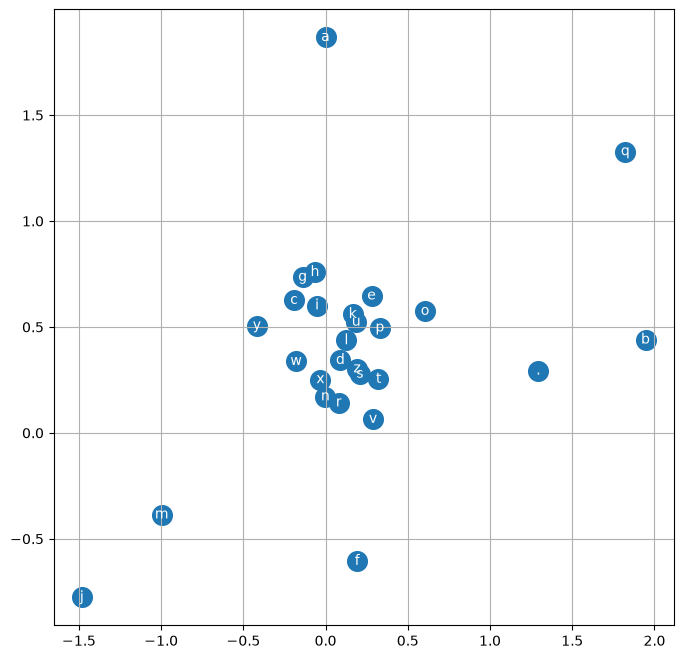

In [279]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

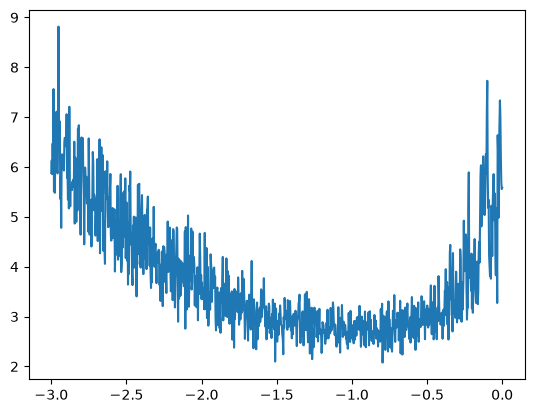

In [184]:
# LEARNING_RATE-LOSS PLOT
# The plot shows that the best learning rate is with the exponent between -1 and -0.5
# plt.plot(lri, lossi)

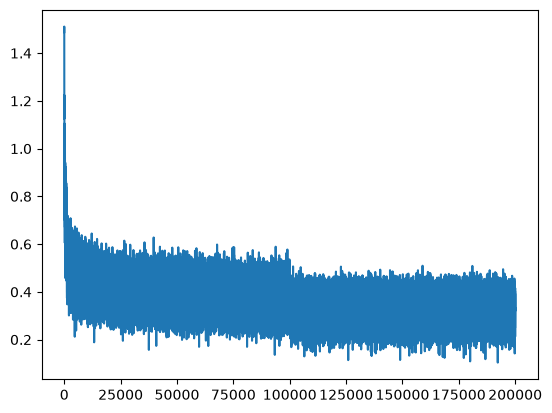

In [290]:
# STEP-LOSS PLOT
# The noise of oscilations is due to minibatches
plt.plot(stepi, lossi)

In [293]:
# sample from the model
g = torch.Generator().manual_seed(2147483647+1)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

iri.
kevey.
zhaileee.
saydaner.
miratta.
rie.
alicies.
kya.
madhahmir.
edin.
rook.
kel.
el.
matastiyan.
sulia.
arosuei.
reighn.
khylanilamillh.
avrie.
ruse.


**Exercises:**
- E01: Tune the hyperparameters of the training to beat my best validation loss of 2.2
- E02: I was not careful with the intialization of the network in this video. (1) What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? What loss do we achieve? (2) Can you tune the initialization to get a starting loss that is much more similar to (1)?
- E03: Read the Bengio et al 2003 paper (link above), implement and try any idea from the paper. Did it work?